# Geneva Chlorophyll-a Climatology

This notebook calculates a day-of-year climatology from the Geneva satellite chlorophyll-a summary. The primary variable is `Mean (mg m-3)`. Multiple satellite scenes on the same UTC calendar day are combined into one daily mean before calculating the climatology. Available 2026 observations are overlaid.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
INPUT_CSV = PROJECT_DIR / "data" / "geneva_chlorophyll_satellite_summary.csv"
OUTPUT_CSV = PROJECT_DIR / "results" / "geneva_chlorophyll_a_climatology.csv"
OUTPUT_DAILY_CSV = PROJECT_DIR / "results" / "geneva_chlorophyll_a_daily.csv"
OUTPUT_PNG = PROJECT_DIR / "graphs" / "geneva_chlorophyll_a_climatology.png"
(PROJECT_DIR / "results").mkdir(exist_ok=True)
(PROJECT_DIR / "graphs").mkdir(exist_ok=True)
assert INPUT_CSV.is_file(), f"Missing input file: {INPUT_CSV}"

## 1. Load and Validate the Satellite Summary

Validate the timestamp and chlorophyll-a mean fields before aggregation. Non-numeric or negative chlorophyll values are excluded.

In [5]:
satellite = pd.read_csv(INPUT_CSV)
expected_columns = {"Datetime", "Satellite", "Mean (mg m-3)", "Min (mg m-3)", "Max (mg m-3)", "Pixel Coverage (%)", "URL"}
assert expected_columns.issubset(satellite.columns)

satellite["timestamp"] = pd.to_datetime(satellite["Datetime"], utc=True, errors="coerce")
satellite["chl_a_mean_mg_m3"] = pd.to_numeric(satellite["Mean (mg m-3)"], errors="coerce")
satellite = satellite[satellite["timestamp"].notna() & satellite["chl_a_mean_mg_m3"].notna() & (satellite["chl_a_mean_mg_m3"] >= 0)].copy()
print("Rows:", len(satellite))
print("Years:", satellite["timestamp"].dt.year.min(), "-", satellite["timestamp"].dt.year.max())
print("2026 observations:", (satellite["timestamp"].dt.year == 2026).sum())
print(satellite[["chl_a_mean_mg_m3", "Pixel Coverage (%)"]].describe())
satellite.head()

Rows: 2978
Years: 2016 - 2026
2026 observations: 233
       chl_a_mean_mg_m3  Pixel Coverage (%)
count       2978.000000         2978.000000
mean           4.636835           29.403962
std            2.955123           29.351901
min            0.000760            1.000000
25%            2.624553            2.000000
50%            3.694955           18.000000
75%            5.842865           55.000000
max           47.090080           91.000000


,Datetime,Satellite,Mean (mg m-3),Min (mg m-3),Max (mg m-3),Pixel Coverage (%),URL,timestamp,chl_a_mean_mg_m3
0,2016-05-04T09:31:00.000+00:00,S3A,3.52345,2.18009,11.58448,70,https://eawagrs.s3.eu-central-1.amazonaws.com/...,2016-05-04 09:31:00+00:00,3.52345
1,2016-05-06T10:20:00.000+00:00,S3A,2.88920,1.95103,14.72065,84,https://eawagrs.s3.eu-central-1.amazonaws.com/...,2016-05-06 10:20:00+00:00,2.88920
2,2016-04-28T10:27:00.000+00:00,S3A,5.32535,2.23020,10.51503,4,https://eawagrs.s3.eu-central-1.amazonaws.com/...,2016-04-28 10:27:00+00:00,5.32535
3,2016-05-03T09:57:00.000+00:00,S3A,3.47746,2.21855,5.29571,2,https://eawagrs.s3.eu-central-1.amazonaws.com/...,2016-05-03 09:57:00+00:00,3.47746
4,2016-05-02T10:24:00.000+00:00,S3A,3.42570,2.31166,11.51469,11,https://eawagrs.s3.eu-central-1.amazonaws.com/...,2016-05-02 10:24:00+00:00,3.42570


## 2. Aggregate to Daily Values and Calculate Climatology

Satellite scenes are sparse and may occur more than once per day. This step averages same-day scenes, then calculates the mean and standard deviation for each day of year.

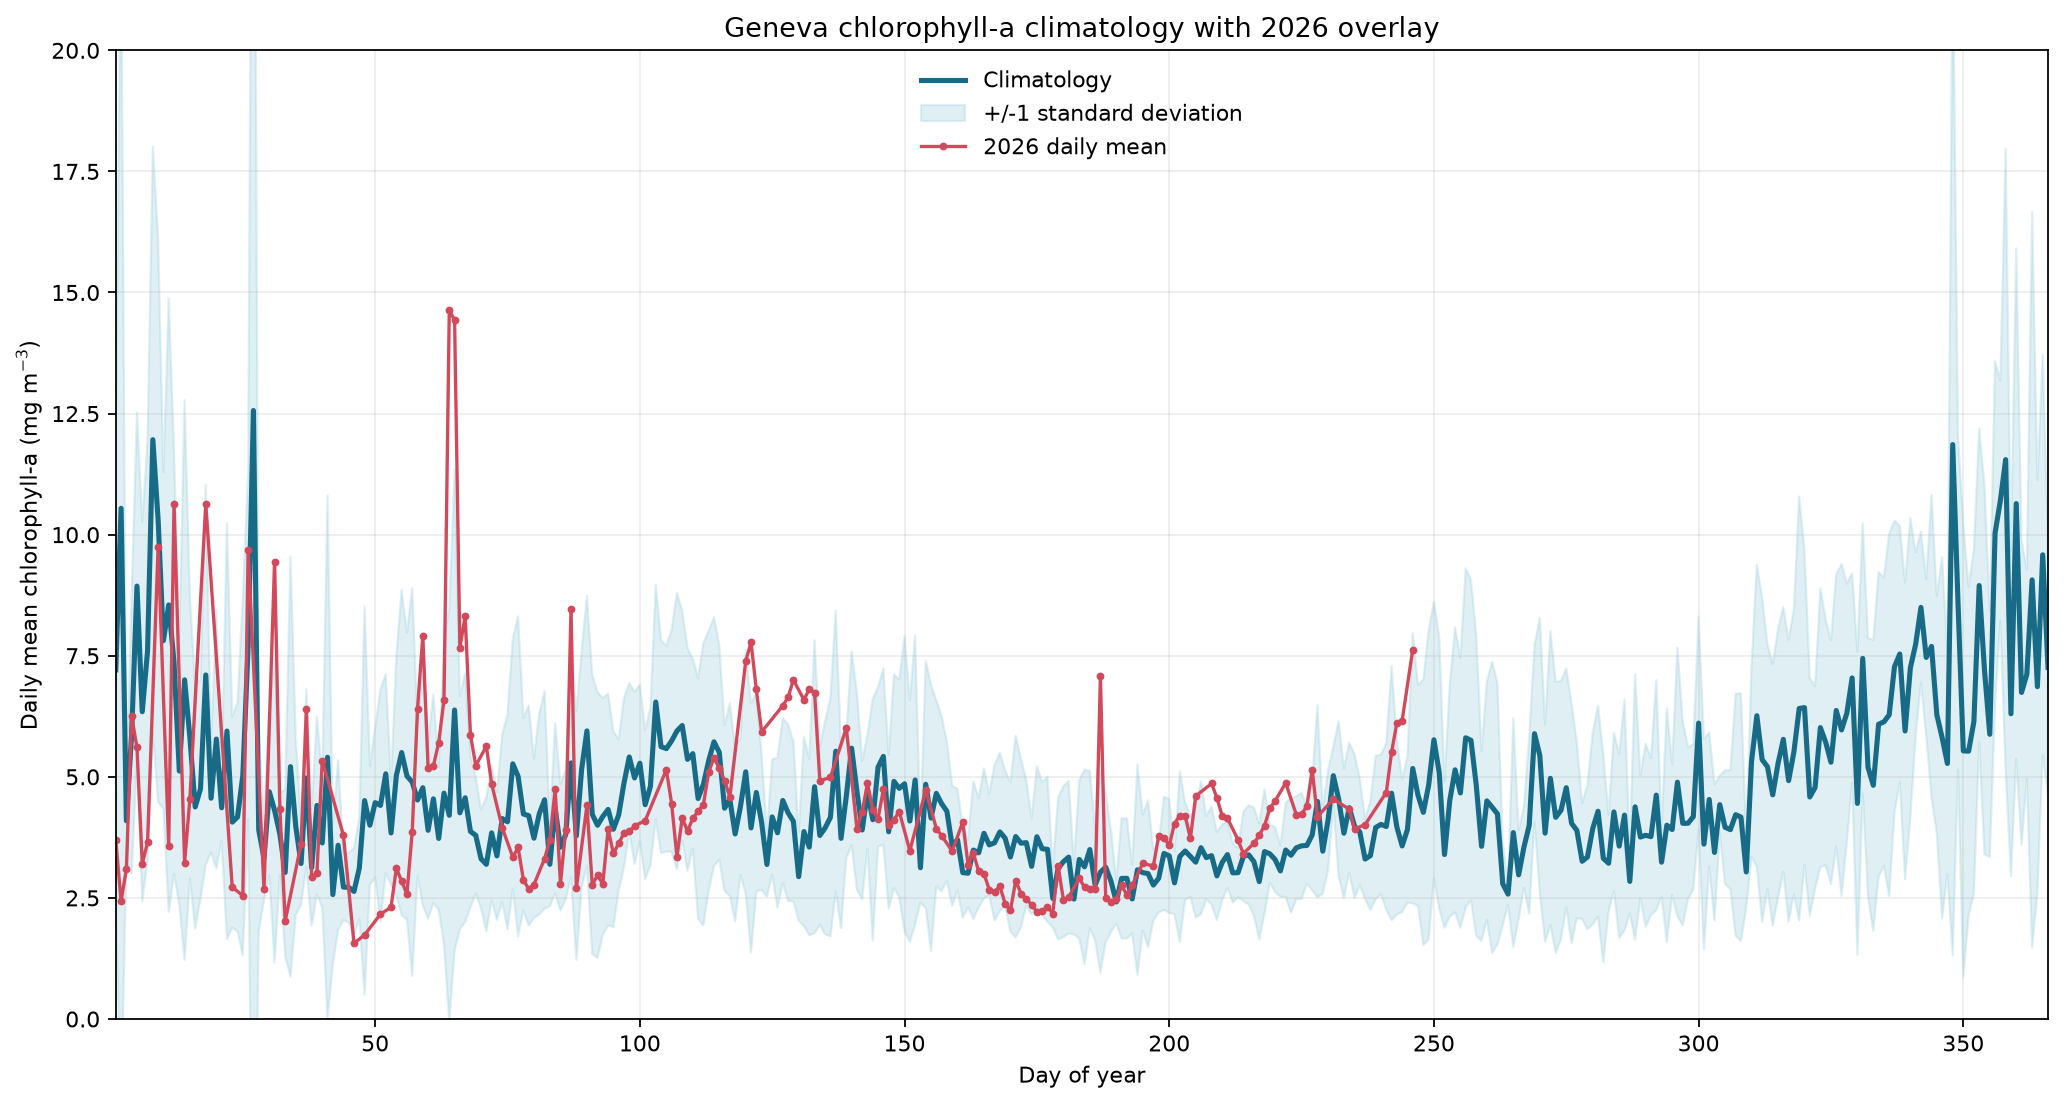

Daily records: 2316
Years: 2016 - 2026
2026 daily records: 180


In [4]:
satellite["date"] = satellite["timestamp"].dt.floor("D")
daily = satellite.groupby("date")["chl_a_mean_mg_m3"].agg(daily_mean="mean", daily_min="min", daily_max="max", scenes="count").reset_index()
daily["year"] = daily["date"].dt.year
daily["day_of_year"] = daily["date"].dt.dayofyear

climatology = daily.groupby("day_of_year")["daily_mean"].agg(climatology_mean="mean", climatology_std="std", years_observed="count", days_observed="size").reset_index()
year_2026 = daily[daily["year"] == 2026]

figure, axis = plt.subplots(figsize=(13, 7), dpi=160)
axis.plot(climatology["day_of_year"], climatology["climatology_mean"], color="#176b87", linewidth=2.3, label="Climatology")
axis.fill_between(climatology["day_of_year"], climatology["climatology_mean"] - climatology["climatology_std"], climatology["climatology_mean"] + climatology["climatology_std"], color="#8ec9d8", alpha=0.28, label="+/-1 standard deviation")
axis.plot(year_2026["day_of_year"], year_2026["daily_mean"], color="#d1495b", linewidth=1.5, marker="o", markersize=2.5, label="2026 daily mean")
axis.set_title("Geneva chlorophyll-a climatology with 2026 overlay")
axis.set_xlabel("Day of year")
axis.set_ylabel("Daily mean chlorophyll-a (mg m$^{-3}$)")
axis.set_xlim(1, 366)
axis.set_ylim(0, 20)
axis.grid(True, alpha=0.22)
axis.legend(frameon=False)
figure.tight_layout()
figure.savefig(OUTPUT_PNG, bbox_inches="tight")
plt.show()

print("Daily records:", len(daily))
print("Years:", daily["year"].min(), "-", daily["year"].max())
print("2026 daily records:", len(year_2026))

## 3. Save Results

Export the daily satellite aggregation and day-of-year climatology for reuse.

In [ ]:
daily.to_csv(OUTPUT_DAILY_CSV, index=False)
climatology.to_csv(OUTPUT_CSV, index=False)
assert len(climatology) > 0
assert OUTPUT_CSV.is_file()
assert OUTPUT_DAILY_CSV.is_file()
assert OUTPUT_PNG.is_file()
print(f"Saved: {OUTPUT_DAILY_CSV.name}")
print(f"Saved: {OUTPUT_CSV.name}")
print(f"Saved: {OUTPUT_PNG.name}")

## 4. Annual Violin Plot of Mean Chlorophyll-a

Compare the distribution of daily mean chlorophyll-a concentrations by year for DOY 150-240. Red lines indicate yearly medians.

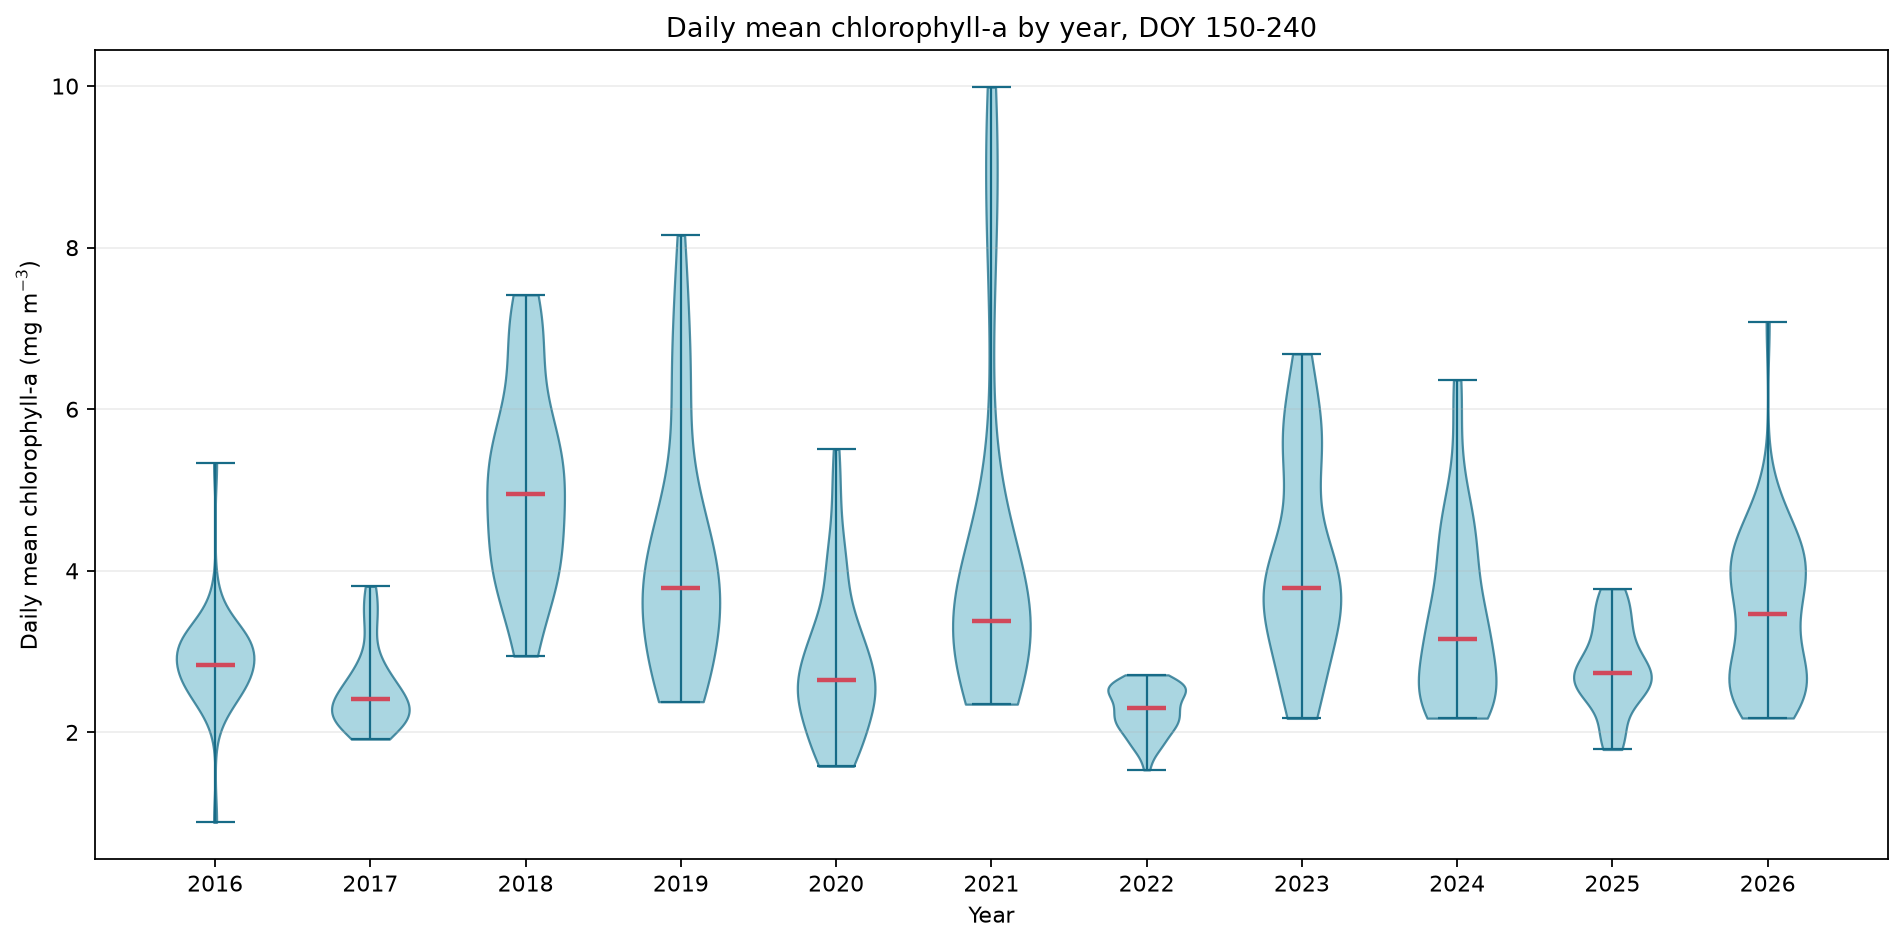

Years plotted: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Total daily mean values plotted: 643
Saved: geneva_daily_mean_chlorophyll_a_violin_by_year_doy150_240.png


In [6]:
DOY_START, DOY_END = 150, 240
if "daily" not in globals():
    if OUTPUT_DAILY_CSV.is_file():
        daily = pd.read_csv(OUTPUT_DAILY_CSV, parse_dates=["date"])
    else:
        satellite["date"] = satellite["timestamp"].dt.floor("D")
        daily = (
            satellite.groupby("date")["chl_a_mean_mg_m3"]
            .agg(
                daily_mean="mean",
                daily_min="min",
                daily_max="max",
                scenes="count",
            )
            .reset_index()
        )

    daily["year"] = daily["date"].dt.year
    daily["day_of_year"] = daily["date"].dt.dayofyear

seasonal_daily = daily[
    daily["day_of_year"].between(DOY_START, DOY_END)
].copy()
violin_years = sorted(seasonal_daily["year"].unique())
violin_values = [seasonal_daily.loc[seasonal_daily["year"] == year, "daily_mean"].dropna() for year in violin_years]
assert violin_years

figure, axis = plt.subplots(figsize=(12, 6), dpi=160)
parts = axis.violinplot(violin_values, positions=np.arange(1, len(violin_years) + 1), showmeans=False, showmedians=True, showextrema=True)
for body in parts["bodies"]:
    body.set_facecolor("#8ec9d8")
    body.set_edgecolor("#176b87")
    body.set_alpha(0.75)
for key in ("cmedians", "cmins", "cmaxes", "cbars"):
    parts[key].set_color("#d1495b" if key == "cmedians" else "#176b87")
    parts[key].set_linewidth(2 if key == "cmedians" else 1)
axis.set_xticks(np.arange(1, len(violin_years) + 1), labels=violin_years)
axis.set_title(f"Daily mean chlorophyll-a by year, DOY {DOY_START}-{DOY_END}")
axis.set_xlabel("Year")
axis.set_ylabel("Daily mean chlorophyll-a (mg m$^{-3}$)")
axis.grid(True, axis="y", alpha=0.22)
figure.tight_layout()
MEAN_CHLA_VIOLIN_PNG = PROJECT_DIR / "graphs" / "geneva_daily_mean_chlorophyll_a_violin_by_year_doy150_240.png"
figure.savefig(MEAN_CHLA_VIOLIN_PNG, bbox_inches="tight")
plt.show()

print(f"Years plotted: {violin_years}")
print(f"Total daily mean values plotted: {len(seasonal_daily):,}")
print(f"Saved: {MEAN_CHLA_VIOLIN_PNG.name}")